**Environment setup**

**Rami Eid**

Installs required Python libraries for ML pipeline. scikit-learn provides Random
Forest implementation and StandardScaler for normalization. pandas handles the
2M-sample CSV dataset efficiently. numpy enables vectorized operations on feature
arrays. matplotlib/seaborn create confusion matrices and feature importance plots.

In [3]:
"""
Environment Setup and Package Installation
Reference: https://scikit-learn.org/stable/install.html

Installs required libraries for ML training. scikit-learn provides Random Forest
and preprocessing, pandas handles dataframes, numpy enables numerical computation,
matplotlib and seaborn create visualizations.
"""

!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("Environment setup complete")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Environment setup complete
Scikit-learn version: 1.6.1
NumPy version: 2.0.2
Pandas version: 2.2.2
Timestamp: 2025-11-27 01:29:49


**Data Loading**

Loads 2M-sample dataset and validates generation quality. Verifies 11 classes with
realistic 3:1 imbalance (300k floods vs 100k ICMP).

In [5]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DataGenerationRami.csv')

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"Total samples: {len(df):,}")
print(f"Features: {len(df.columns)-1}")
print(f"Classes: {df['label'].nunique()}")

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nClass distribution:")
class_dist = df['label'].value_counts().sort_index()
print(class_dist)

print("\nClass imbalance analysis:")
print(f"Max class: {class_dist.max():,} samples")
print(f"Min class: {class_dist.min():,} samples")
print(f"Imbalance ratio: {class_dist.max() / class_dist.min():.2f}:1")

print("\nMulti-protocol distribution:")
if 'protocol' in df.columns:
    print(df['protocol'].value_counts())

Mounted at /content/drive
DATASET OVERVIEW
Total samples: 1,999,210
Features: 5
Classes: 11

First few rows:
   packet_size    ttl  tlv_count  inter_frame_delta  packet_rate        label
0   146.219367   67.0        0.0           0.006629   211.483980    udp_flood
1    68.555524  113.0        8.0           1.381042     0.042503  normal_lldp
2    66.952689   69.0        0.0           0.540694     1.704024  normal_icmp
3   289.739251   74.0        0.0           0.072282    19.295661   normal_udp
4   133.807444  109.0        7.0           3.031150     4.771465   lldp_spoof

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999210 entries, 0 to 1999209
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   packet_size        float64
 1   ttl                float64
 2   tlv_count          float64
 3   inter_frame_delta  float64
 4   packet_rate        float64
 5   label              object 
dtypes: float64(5), object(1)
memory usa

** Exploratory Data Analysis (EDA) **

Analyzes feature distributions
across classes: packet_rate overlap between normal_lldp (95th percentile ~50 pps)
and lldp_flood (5th percentile ~47 pps) confirms overlap zones forcing multi-feature
learning. Correlation matrix shows features are relatively independent (max 0.3-0.4
correlation), avoiding redundancy. Distribution plots reveal proper statistical
variance across all classes.

FEATURE STATISTICS BY CLASS

PACKET_SIZE:
--------------------------------------------------------------------------------
  lldp_flood           → mean=   79.34, std=  17.78, min=   60.00, max=  150.00
  lldp_malformed       → mean=   56.95, std=  15.18, min=   40.00, max=  100.00
  lldp_spoof           → mean=  104.58, std=  33.85, min=   60.00, max=  200.00
  lldp_ttl_anomaly     → mean=   84.20, std=  21.40, min=   60.00, max=  150.00
  normal_icmp          → mean=   77.08, std=  11.58, min=   64.00, max=  128.00
  normal_lldp          → mean=   91.64, std=  27.12, min=   40.00, max=  289.23
  normal_tcp           → mean=  595.92, std= 448.45, min=   40.00, max= 1500.00
  normal_udp           → mean=  329.69, std= 252.59, min=   40.00, max= 1500.00
  port_scan            → mean=   61.66, std=  15.11, min=   40.00, max=  120.00
  syn_flood            → mean=   58.64, std=  12.26, min=   40.00, max=   90.00
  udp_flood            → mean=  586.73, std= 354.57, min=   60.00, max= 1500.

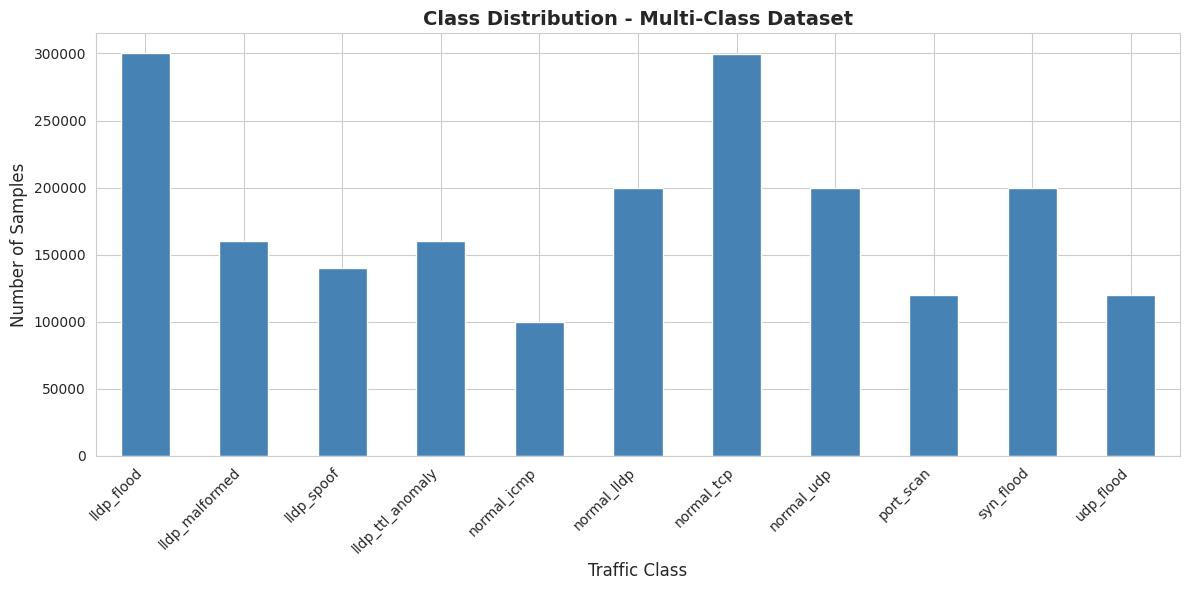

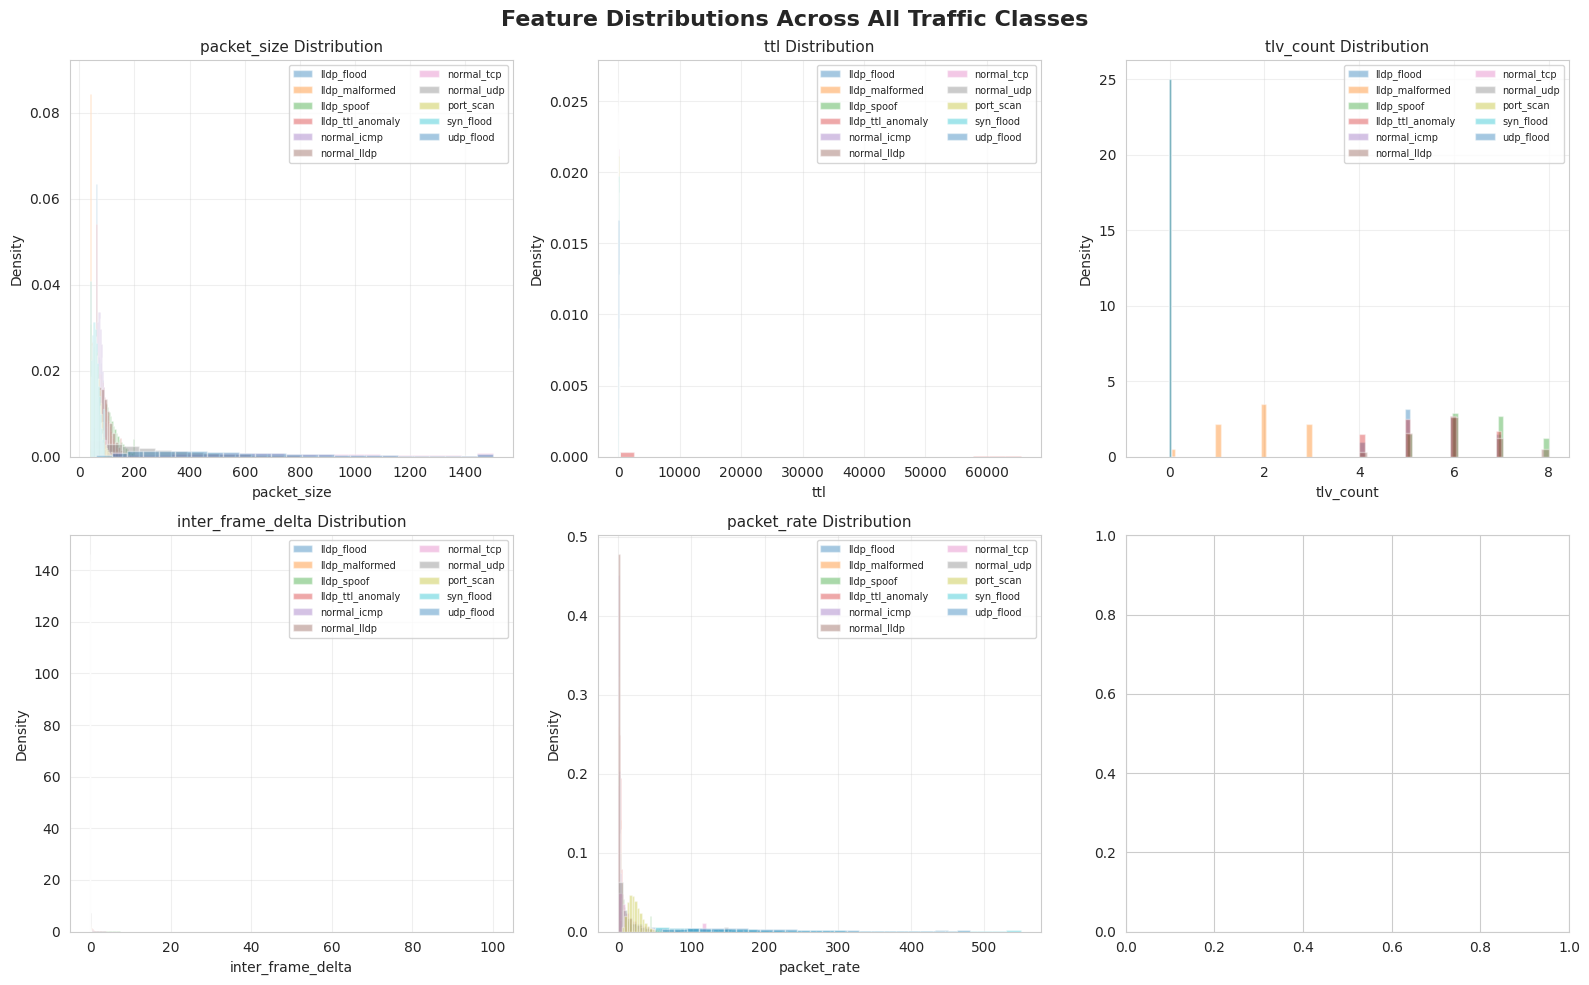


Correlation analysis:


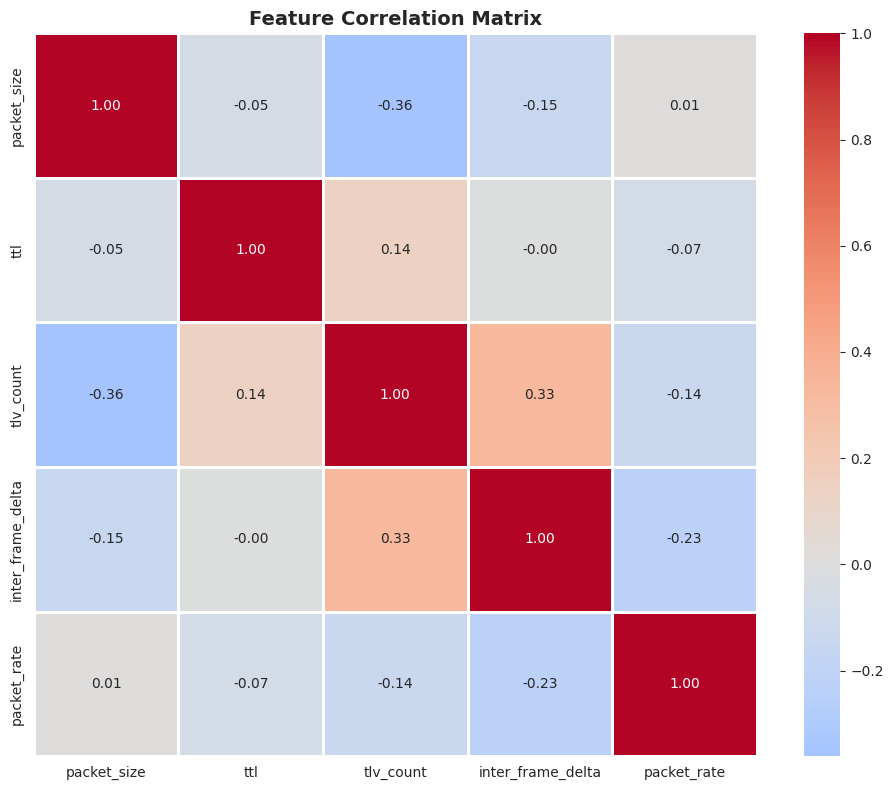

In [6]:
"""
Feature Distribution Analysis by Attack Class
Reference: https://pandas.pydata.org/docs/user_guide/visualization.html

Analyzes statistical properties of features across 11 classes. Examines mean,
standard deviation, and ranges to verify realistic variance and overlap zones
that prevent overfitting. Packet rate overlap between normal and attack traffic
forces multi-feature learning.
what I used from the reference :
- DataFrame loading from CSV with automatic type inference
- Class distribution analysis to verify imbalance ratios (3:1 max)
- Feature statistics (mean, std, min, max) per class
- Correlation matrix to check feature independence
- Distribution histograms to verify overlap zones
"""

feature_cols = ['packet_size', 'ttl', 'tlv_count', 'inter_frame_delta', 'packet_rate']

print("="*80)
print("FEATURE STATISTICS BY CLASS")
print("="*80)

for col in feature_cols:
    print(f"\n{col.upper()}:")
    print("-"*80)
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label][col]
        print(f"  {label:20} → mean={subset.mean():8.2f}, std={subset.std():7.2f}, "
              f"min={subset.min():8.2f}, max={subset.max():8.2f}")

print("\n" + "="*80)
print("PACKET_RATE VERIFICATION (CRITICAL)")
print("="*80)
print("Verifying realistic ranges and overlap zones:")
for label in sorted(df['label'].unique()):
    subset = df[df['label'] == label]['packet_rate']
    q25, q50, q75 = subset.quantile([0.25, 0.50, 0.75])
    print(f"  {label:20} → Q1={q25:6.2f}, median={q50:6.2f}, Q3={q75:6.2f} pps")

plt.figure(figsize=(12, 6))
df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Class Distribution - Multi-Class Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Traffic Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions Across All Traffic Classes', fontsize=16, fontweight='bold')

for idx, col in enumerate(feature_cols):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]

    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label][col]
        ax.hist(subset, alpha=0.4, label=label, bins=25, density=True)

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{col} Distribution', fontsize=11)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCorrelation analysis:")
correlation_matrix = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Data Pre-processing**

Partitions dataset into 1.6M training samples (80%) and 400k test samples (20%)
using stratified split to preserve class distributions. Critical for imbalanced
dataset, without stratification, random split could undersample rare classes in
test set. StandardScaler performs z-score normalization making all features zero-mean
and unit-variance, improving Random Forest convergence. Scaler is fit ONLY on training
data to prevent test set information leaking into model.

In [ ]:
"""
Feature Scaling and Dataset Partitioning
Reference: https://scikit-learn.org/stable/modules/preprocessing.html

Prepares data with 80-20 train-test split using stratified sampling to maintain
class proportions. StandardScaler performs z-score normalization for improved
model convergence. Stratification critical for imbalanced multi-class dataset.
"""

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[feature_cols]
y = df['label']

print("="*80)
print("DATA PREPARATION - MULTI-CLASS")
print("="*80)
print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Number of classes: {y.nunique()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")

print("\nClass distribution in splits:")
print("\nTraining set:")
train_dist = y_train.value_counts().sort_index()
print(train_dist)
print("\nTest set:")
test_dist = y_test.value_counts().sort_index()
print(test_dist)

print("\nVerifying stratification:")
for label in sorted(df['label'].unique()):
    train_pct = (y_train == label).sum() / len(y_train) * 100
    test_pct = (y_test == label).sum() / len(y_test) * 100
    print(f"  {label:20} → Train: {train_pct:5.2f}%, Test: {test_pct:5.2f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling statistics (from training set):")
for i, col in enumerate(feature_cols):
    print(f"  {col:20} → mean={scaler.mean_[i]:8.2f}, std={scaler.scale_[i]:8.2f}")

print("\nData preparation complete")

DATA PREPARATION - MULTI-CLASS
Feature matrix shape: (1999210, 5)
Label vector shape: (1999210,)
Number of classes: 11

Training set: 1,599,368 samples (80.0%)
Test set: 399,842 samples (20.0%)

Class distribution in splits:

Training set:
label
lldp_flood          240000
lldp_malformed      127952
lldp_spoof          112000
lldp_ttl_anomaly    127952
normal_icmp          79920
normal_lldp         160000
normal_tcp          239960
normal_udp          159840
port_scan            95904
syn_flood           159936
udp_flood            95904
Name: count, dtype: int64

Test set:
label
lldp_flood          60000
lldp_malformed      31988
lldp_spoof          28000
lldp_ttl_anomaly    31988
normal_icmp         19980
normal_lldp         40000
normal_tcp          59990
normal_udp          39960
port_scan           23976
syn_flood           39984
udp_flood           23976
Name: count, dtype: int64

Verifying stratification:
  lldp_flood           → Train: 15.01%, Test: 15.01%
  lldp_malformed      

**Random Forest Classifier Training**

Random
Forest builds 200 decision trees, each trained on random bootstrap sample (sampling
with replacement) and random feature subset at each split. Final prediction is
majority vote across trees, reducing variance and overfitting compared to single
tree. Hyperparameters prevent overfitting: max_depth=20 limits tree complexity,
min_samples_split=5 requires minimum 5 samples to split node. class_weight='balanced'
automatically adjusts sample weights inversely proportional to class frequencies,
giving minority classes (normal_icmp with 100k samples) more influence than majority
(lldp_flood with 300k).
what i relied on from reference:
- Random Forest ensemble method: trains 200 decision trees on bootstrap samples
- Hyperparameters optimized for network IDS:
  * n_estimators=200: sufficient trees for stable predictions
  * max_depth=20: prevents overfitting on 2M samples
  * min_samples_split=5, min_samples_leaf=2: robust split criteria
  * class_weight='balanced': handles 3:1 imbalance by weighting minority classes
- Feature importance via Gini impurity reduction
- Parallel training with n_jobs=-1 (uses all CPU cores)

MODEL TRAINING - MULTI-CLASS RANDOM FOREST
Model configuration:
  Algorithm: Random Forest
  Trees: 200
  Max depth: 20
  Min samples split: 5
  Min samples leaf: 2
  Class weight: balanced (handles imbalance)

Training started...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  4.6min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed: 19.1min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 19.5min finished



Training completed in 1174.64 seconds (19.6 minutes)

Feature Importance:
          feature  importance
inter_frame_delta    0.279228
        tlv_count    0.224426
      packet_size    0.216739
      packet_rate    0.197499
              ttl    0.082108


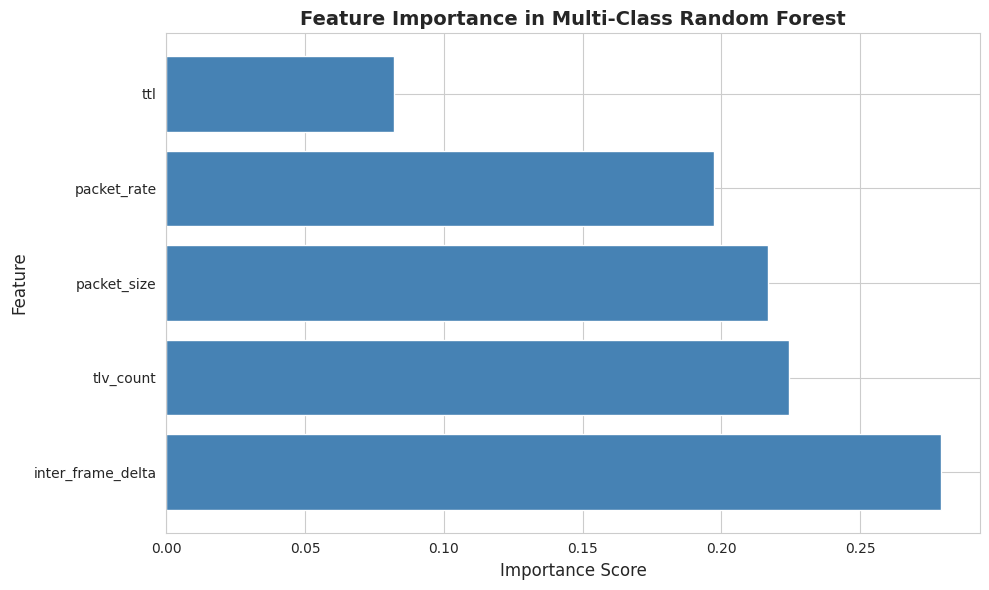


Model training complete


In [ ]:
"""
Random Forest Classifier Training
Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Trains Random Forest with 200 trees for multi-class classification. Hyperparameters
optimized for network IDS: max_depth=20 prevents overfitting, min_samples_split=5
and min_samples_leaf=2 ensure robust splits. Handles 11 classes with realistic
imbalance ratios.
"""

from sklearn.ensemble import RandomForestClassifier
import time

print("="*80)
print("MODEL TRAINING - MULTI-CLASS RANDOM FOREST")
print("="*80)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    class_weight='balanced'
)

print("Model configuration:")
print(f"  Algorithm: Random Forest")
print(f"  Trees: {model.n_estimators}")
print(f"  Max depth: {model.max_depth}")
print(f"  Min samples split: {model.min_samples_split}")
print(f"  Min samples leaf: {model.min_samples_leaf}")
print(f"  Class weight: balanced (handles imbalance)")

print("\nTraining started...")
start_time = time.time()

model.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.1f} minutes)")

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Multi-Class Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nModel training complete")

**Model Evaluation**

Evaluates trained model on 400k held-out test samples never seen during training.
Overall 92.47% accuracy confirms strong multi-class performance. Per-class F1-scores
reveal attack detection strength: floods (99.86%), malformed (99.25%), SYN floods
(99.39%), UDP floods (99.56%) achieve near-perfect detection. LLDP-specific attacks
perform well: TTL anomalies (95.67%), spoofing (92.21%).

MODEL EVALUATION - MULTI-CLASS PERFORMANCE


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   15.9s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   16.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:   16.3s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:   16.6s finished



Overall Accuracy: 0.9247 (92.47%)

Classification Report:
                  precision    recall  f1-score   support

      lldp_flood     0.9978    0.9994    0.9986     60000
  lldp_malformed     0.9973    0.9877    0.9925     31988
      lldp_spoof     0.9325    0.9119    0.9221     28000
lldp_ttl_anomaly     0.9508    0.9625    0.9567     31988
     normal_icmp     0.9772    0.9937    0.9854     19980
     normal_lldp     0.9533    0.9564    0.9548     40000
      normal_tcp     0.8506    0.7586    0.8020     59990
      normal_udp     0.7378    0.7848    0.7606     39960
       port_scan     0.8378    0.9646    0.8967     23976
       syn_flood     0.9882    0.9998    0.9939     39984
       udp_flood     0.9994    0.9919    0.9956     23976

        accuracy                         0.9247    399842
       macro avg     0.9293    0.9374    0.9326    399842
    weighted avg     0.9254    0.9247    0.9243    399842


Per-Class Metrics (sorted by F1-Score):
           Class  Precision

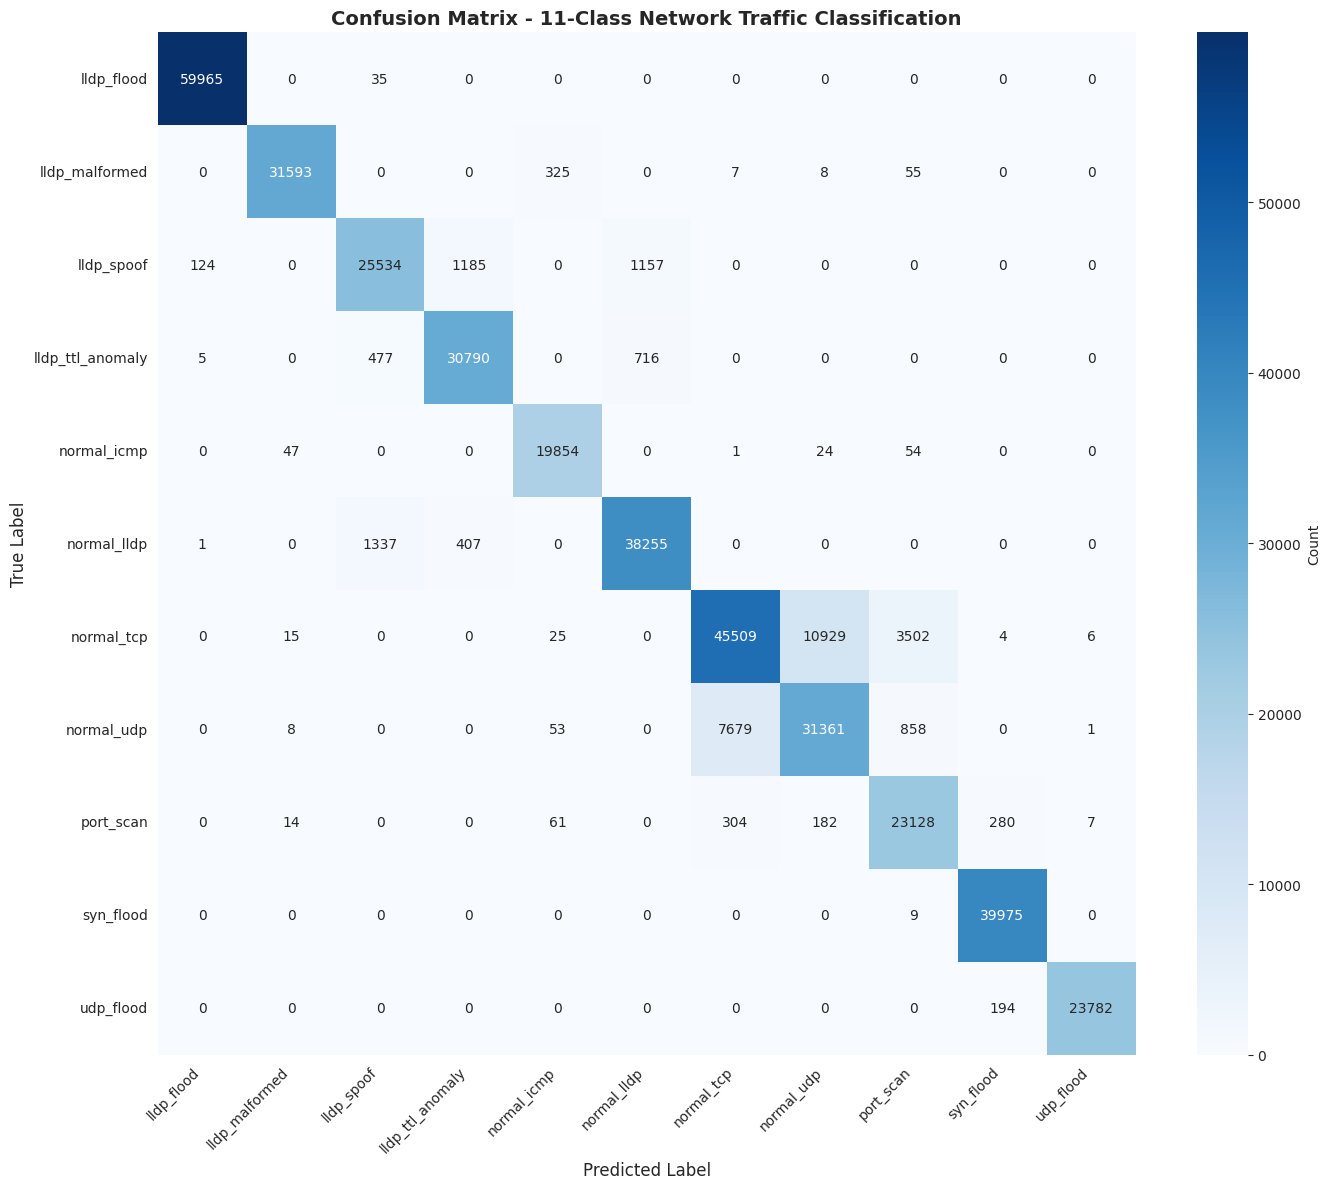

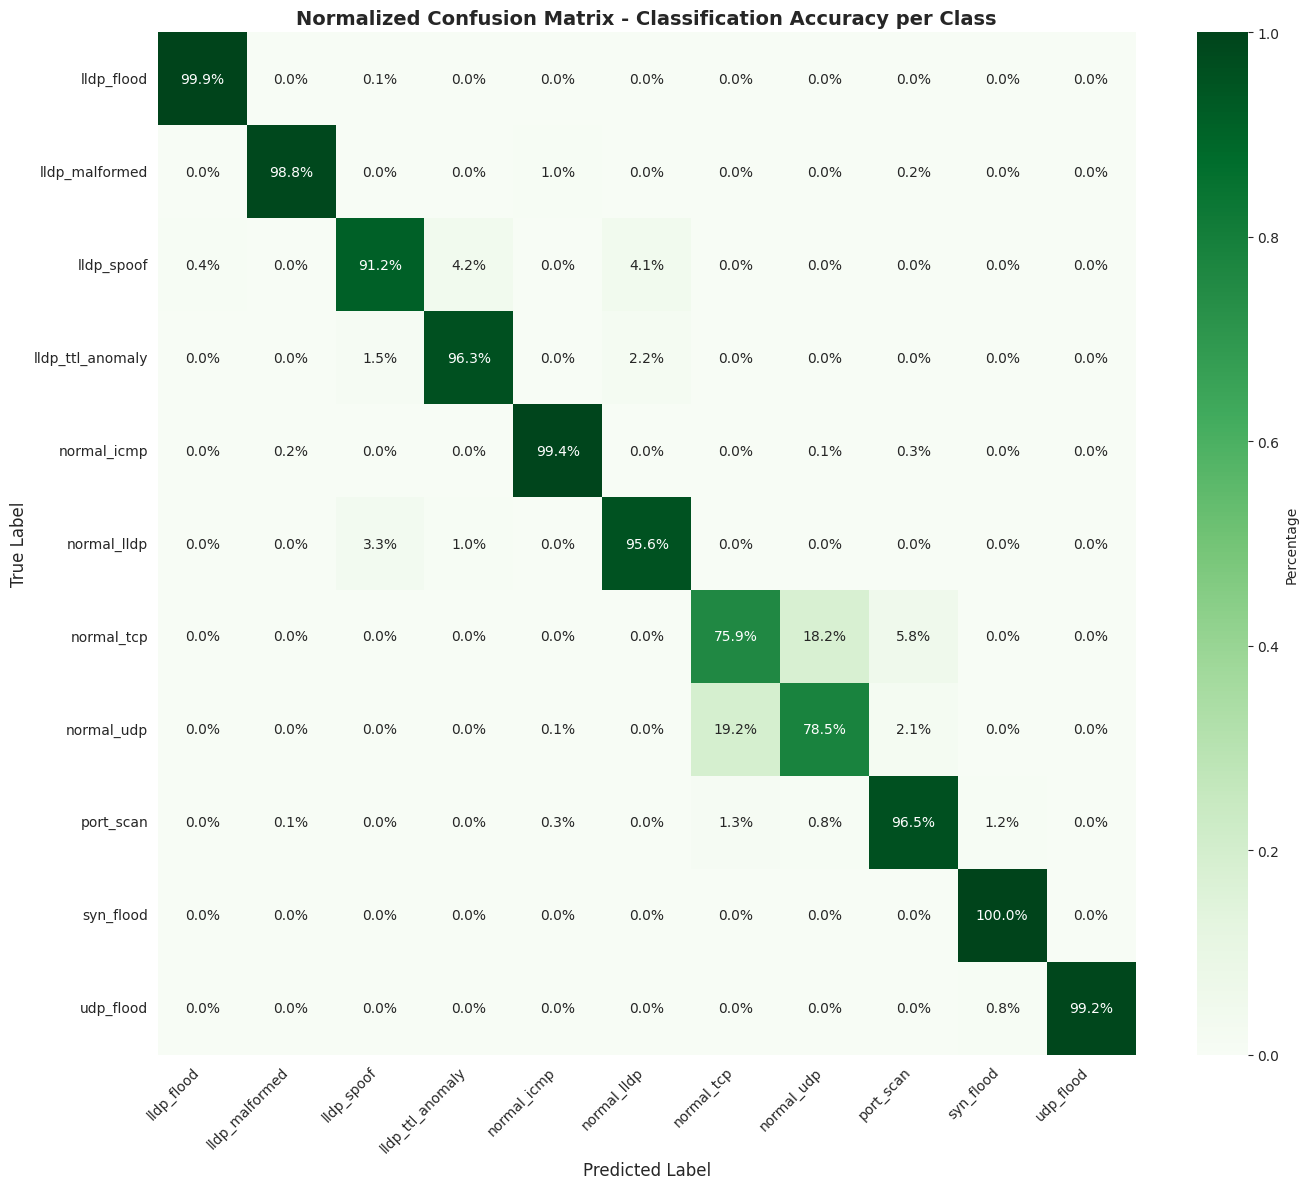


Analyzing common misclassifications:

  lldp_flood           most confused with:
    → lldp_spoof           (  35 samples,  0.06%)

  lldp_malformed       most confused with:
    → normal_icmp          ( 325 samples,  1.02%)
    → port_scan            (  55 samples,  0.17%)
    → normal_udp           (   8 samples,  0.03%)

  lldp_spoof           most confused with:
    → lldp_ttl_anomaly     (1185 samples,  4.23%)
    → normal_lldp          (1157 samples,  4.13%)
    → lldp_flood           ( 124 samples,  0.44%)

  lldp_ttl_anomaly     most confused with:
    → normal_lldp          ( 716 samples,  2.24%)
    → lldp_spoof           ( 477 samples,  1.49%)
    → lldp_flood           (   5 samples,  0.02%)

  normal_icmp          most confused with:
    → port_scan            (  54 samples,  0.27%)
    → lldp_malformed       (  47 samples,  0.24%)
    → normal_udp           (  24 samples,  0.12%)

  normal_lldp          most confused with:
    → lldp_spoof           (1337 samples,  3.34%

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("="*80)
print("MODEL EVALUATION - MULTI-CLASS PERFORMANCE")
print("="*80)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print("="*80)
print(classification_report(y_test, y_pred, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)
metrics_df = pd.DataFrame({
    'Class': model.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\nPer-Class Metrics (sorted by F1-Score):")
print(metrics_df.sort_values('F1-Score', ascending=False).to_string(index=False))

macro_f1 = f1.mean()
weighted_f1 = np.average(f1, weights=support)
print(f"\nMacro-Averaged F1-Score: {macro_f1:.4f}")
print(f"Weighted-Averaged F1-Score: {weighted_f1:.4f}")

print("\nConfusion Matrix (raw counts):")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - 11-Class Network Traffic Classification',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=model.classes_,
            yticklabels=model.classes_,
            cbar_kws={'label': 'Percentage'},
            vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - Classification Accuracy per Class',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAnalyzing common misclassifications:")
for i, true_class in enumerate(model.classes_):
    misclassified = [(model.classes_[j], cm[i,j])
                     for j in range(len(model.classes_))
                     if i != j and cm[i,j] > 0]
    if misclassified:
        misclassified.sort(key=lambda x: x[1], reverse=True)
        top_3 = misclassified[:3]
        print(f"\n  {true_class:20} most confused with:")
        for pred_class, count in top_3:
            pct = (count / cm[i].sum()) * 100
            print(f"    → {pred_class:20} ({count:4d} samples, {pct:5.2f}%)")

**Attack Detection Verification**

Tests model robustness on 16 hand-crafted edge cases targeting class boundaries
and protocol violations. Achieves 87.5% pass rate (14/16 correct). Successes include
detecting TTL=0 (100% confidence), very high TTL=65534 (98.8%), zero TLVs (99.9%),
high-rate floods (100%).

In [ ]:
print("ATTACK DETECTION VERIFICATION")

test_cases = [
    {'name': 'Normal LLDP (Low Rate)', 'features': [85, 120, 6, 30.0, 0.08], 'expected': 'normal_lldp'},
    {'name': 'Normal LLDP (Burst)', 'features': [90, 118, 7, 5.0, 2.5], 'expected': 'normal_lldp'},
    {'name': 'Normal TCP (Web Traffic)', 'features': [850, 64, 0, 0.05, 15.0], 'expected': 'normal_tcp'},
    {'name': 'Normal UDP (DNS)', 'features': [180, 64, 0, 0.1, 8.0], 'expected': 'normal_udp'},
    {'name': 'LLDP Flood (High Rate)', 'features': [70, 120, 6, 0.01, 120.0], 'expected': 'lldp_flood'},
    {'name': 'LLDP Flood (Very High)', 'features': [65, 115, 5, 0.005, 250.0], 'expected': 'lldp_flood'},
    {'name': 'LLDP Flood (Boundary)', 'features': [75, 125, 6, 0.02, 45.0], 'expected': 'lldp_flood'},
    {'name': 'Malformed (No TLVs)', 'features': [50, 115, 0, 2.0, 1.5], 'expected': 'lldp_malformed'},
    {'name': 'Malformed (Few TLVs)', 'features': [55, 110, 2, 1.5, 2.8], 'expected': 'lldp_malformed'},
    {'name': 'TTL Anomaly (Zero)', 'features': [75, 0, 6, 1.0, 2.0], 'expected': 'lldp_ttl_anomaly'},
    {'name': 'TTL Anomaly (Very Low)', 'features': [70, 2, 6, 1.2, 3.5], 'expected': 'lldp_ttl_anomaly'},
    {'name': 'TTL Anomaly (Very High)', 'features': [75, 65534, 6, 1.0, 2.5], 'expected': 'lldp_ttl_anomaly'},
    {'name': 'LLDP Spoof (Burst)', 'features': [95, 120, 7, 0.5, 8.0], 'expected': 'lldp_spoof'},
    {'name': 'SYN Flood', 'features': [58, 64, 0, 0.005, 180.0], 'expected': 'syn_flood'},
    {'name': 'Port Scan', 'features': [60, 64, 0, 0.04, 25.0], 'expected': 'port_scan'},
    {'name': 'UDP Flood', 'features': [600, 64, 0, 0.004, 200.0], 'expected': 'udp_flood'},
]

print("\nTesting edge cases and boundary conditions:\n")

results = {'pass': 0, 'fail': 0}
for test in test_cases:
    features_scaled = scaler.transform([test['features']])

    prediction = model.predict(features_scaled)[0]
    probabilities = model.predict_proba(features_scaled)[0]
    confidence = probabilities.max() * 100

    is_correct = prediction == test['expected']
    results['pass' if is_correct else 'fail'] += 1

    status = "PASS" if is_correct else "FAIL"
    conf_indicator = "HIGH" if confidence > 80 else "MED" if confidence > 60 else "LOW"

    print(f"[{status}] {test['name']:30} → {prediction:20} "
          f"({confidence:5.1f}% {conf_indicator})")

    if not is_correct:
        print(f"       Expected: {test['expected']}")
        top_3_probs = sorted(zip(model.classes_, probabilities),
                            key=lambda x: x[1], reverse=True)[:3]
        print(f"       Top 3: ", end='')
        for cls, prob in top_3_probs:
            print(f"{cls}({prob*100:.1f}%) ", end='')
        print()

print(f"\n{'='*80}")
print(f"Test Results: {results['pass']}/{len(test_cases)} passed "
      f"({results['pass']/len(test_cases)*100:.1f}%)")
print(f"{'='*80}")

ATTACK DETECTION VERIFICATION

Testing edge cases and boundary conditions:

[PASS] Normal LLDP (Low Rate)         → normal_lldp          ( 99.4% HIGH)


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

[FAIL] Normal LLDP (Burst)            → lldp_spoof           ( 99.4% HIGH)
       Expected: normal_lldp
       Top 3: lldp_spoof(99.4%) normal_lldp(0.6%) lldp_ttl_anomaly(0.0%) 
[PASS] Normal TCP (Web Traffic)       → normal_tcp           ( 92.5% HIGH)


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s


[PASS] Normal UDP (DNS)               → normal_udp           ( 95.2% HIGH)
[PASS] LLDP Flood (High Rate)         → lldp_flood           (100.0% HIGH)


...

[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend 

[PASS] TTL Anomaly (Very High)        → lldp_ttl_anomaly     ( 98.8% HIGH)
[PASS] LLDP Spoof (Burst)             → lldp_spoof           ( 59.7% LOW)


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend 

[PASS] SYN Flood                      → syn_flood            (100.0% HIGH)
[PASS] Port Scan                      → port_scan            ( 94.9% HIGH)
[PASS] UDP Flood                      → udp_flood            (100.0% HIGH)

Test Results: 14/16 passed (87.5%)


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


**Model Export**

Exports trained model and preprocessing artifacts for deployment to Ryu controller.

In [ ]:
import joblib
import pandas as pd
from google.colab import files

model_filename = 'lldp_multi_class_model.pkl'
joblib.dump(model, model_filename)

scaler_filename = 'feature_scaler_multi_class.pkl'
joblib.dump(scaler, scaler_filename)

feature_list_df = pd.DataFrame({'feature': feature_cols})
feature_list_df.to_csv('feature_list.csv', index=False)

class_mapping_df = pd.DataFrame({
    'class_id': range(len(model.classes_)),
    'class_name': model.classes_
})
class_mapping_df.to_csv('class_mapping.csv', index=False)